# Data Exploartion

#### 1. Load data

In [1]:
import pandas as pd

df = pd.read_csv('./soccer_news_sample.csv')
df.head()

,title,text,url,publisher,dt
0,"""시즌 끝나지도 않았는데, 이비자 여행가서 DJ까지?""...리버풀 몰락 원인 지목한...",[스포티비뉴스=신인섭 기자] 맨체스터 유나이티드 레전드 폴 스콜스가 리버풀의 몰락의...,https://v.daum.net/v/XmOR2fHlvz,스포티비뉴스,5분 전
1,"레알 마드리드 내부 뒤흔든 불화설… 알론소의 여유 있는 정면돌파 “자연스러운 일, ...",[포포투=김호진] 사비 알론소 감독이 팀 내 불화설에 대해 입을 열었다. 영국 ‘스...,https://v.daum.net/v/KyUdQM3GRT,포포투,5분 전
2,"손흥민 초청 이유?.. '레비 떠난' NEW 토트넘, 아이콘 통해 '팬심 결속+정체...",[OSEN=강필주 기자] '레비 시대'를 마감한 'NEW 토트넘'이 구단의 아이콘이...,https://v.daum.net/v/0EvouzlwS6,OSEN,21분 전
3,"배준호 2경기 연속 공격포인트…스토크시티, 찰턴에 3-0 완승",잉글랜드 챔피언십 스토크시티의 배준호가 시즌 두 번째 도움을 기록하며 팀의 완승을 ...,https://v.daum.net/v/xpW1YHAiRG,포모스,23분 전
4,"첼시, 10명 된 바르셀로나 3-0 격파…쿠쿠레야가 야말 완전 봉쇄",첼시가 유럽축구연맹 챔피언스리그(UCL) 리그 페이즈 5차전에서 스페인 강호 바르셀...,https://v.daum.net/v/p8CaK2YCJS,포모스,25분 전


#### 1-1. Data Exploration

In [2]:
# Datetime uniquecounts -- to see how many articles were published on each date
# Finding: All articles were published on 2025-11-26
df['dt'].apply(lambda x: x[:10]).value_counts() # YYYY.MM.DD (10 characters)

dt
2025.11.26    168
5분 전            4
53분 전           4
21분 전           2
23분 전           2
25분 전           2
27분 전           2
31분 전           2
36분 전           2
37분 전           2
40분 전           2
44분 전           2
46분 전           2
50분 전           2
59분 전           2
Name: count, dtype: int64

In [3]:
# Import matplotlib and set up Korean font
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Load NanumSquareRoundR font for Koerean characters
font_path = './NanumSquareRoundR.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)

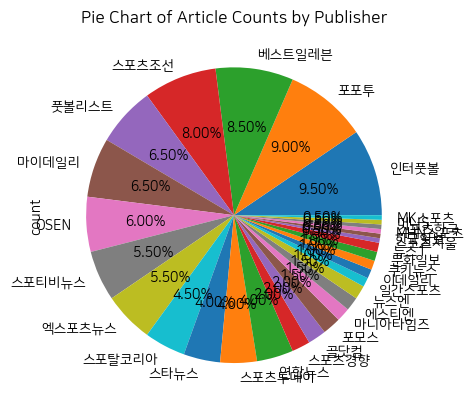

In [4]:
# Publisher uniquecounts -- to see how many articles were published by each publisher
df['publisher'].value_counts().plot.pie(autopct='%.2f%%')
plt.title('Pie Chart of Article Counts by Publisher')
plt.show()

In [5]:
# Get text lengths
df['len'] = df['text'].apply(lambda x: len(x))
df.head()

,title,text,url,publisher,dt,len
0,"""시즌 끝나지도 않았는데, 이비자 여행가서 DJ까지?""...리버풀 몰락 원인 지목한...",[스포티비뉴스=신인섭 기자] 맨체스터 유나이티드 레전드 폴 스콜스가 리버풀의 몰락의...,https://v.daum.net/v/XmOR2fHlvz,스포티비뉴스,5분 전,1423
1,"레알 마드리드 내부 뒤흔든 불화설… 알론소의 여유 있는 정면돌파 “자연스러운 일, ...",[포포투=김호진] 사비 알론소 감독이 팀 내 불화설에 대해 입을 열었다. 영국 ‘스...,https://v.daum.net/v/KyUdQM3GRT,포포투,5분 전,923
2,"손흥민 초청 이유?.. '레비 떠난' NEW 토트넘, 아이콘 통해 '팬심 결속+정체...",[OSEN=강필주 기자] '레비 시대'를 마감한 'NEW 토트넘'이 구단의 아이콘이...,https://v.daum.net/v/0EvouzlwS6,OSEN,21분 전,1360
3,"배준호 2경기 연속 공격포인트…스토크시티, 찰턴에 3-0 완승",잉글랜드 챔피언십 스토크시티의 배준호가 시즌 두 번째 도움을 기록하며 팀의 완승을 ...,https://v.daum.net/v/xpW1YHAiRG,포모스,23분 전,629
4,"첼시, 10명 된 바르셀로나 3-0 격파…쿠쿠레야가 야말 완전 봉쇄",첼시가 유럽축구연맹 챔피언스리그(UCL) 리그 페이즈 5차전에서 스페인 강호 바르셀...,https://v.daum.net/v/p8CaK2YCJS,포모스,25분 전,810


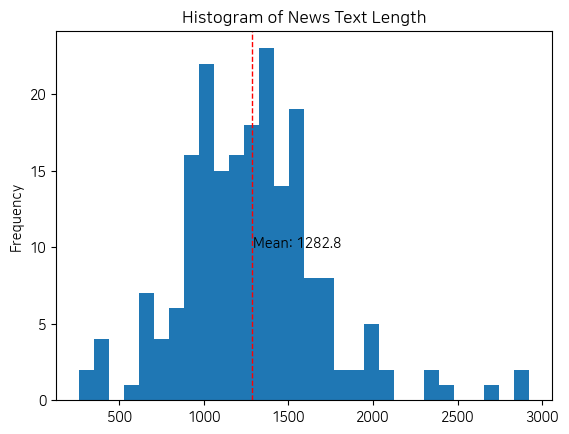

In [6]:
# Plot histogram of news text lengths
df['len'].plot.hist(bins=30)
mean_len = df['len'].mean()
# Add a vertical line for the mean length
plt.axvline(mean_len, color='red', linestyle='dashed', linewidth=1)
# Add text annotation for the mean length
plt.text(mean_len+5, 10, 'Mean: {:.1f}'.format(mean_len), color='black')
# title
plt.title('Histogram of News Text Length')
plt.show()

In [7]:
# Filter and show articles with text length less than 500 characters 
df.loc[df['len'] < 500, ['title', 'text', 'publisher']]

,title,text,publisher
95,EL SALVADOR SOCCER,"epa12549199 Yamil Bukele, president of the gov...",연합뉴스
98,BRAZIL SOCCER,"epa12549150 The director of NR Sports, Neymar ...",연합뉴스
99,BRAZIL SOCCER,epa12549154 Former Brazilian player Pepe react...,연합뉴스
100,BRAZIL SOCCER,epa12549152 An illuminated mural of Pele next ...,연합뉴스
101,BRAZIL SOCCER,"epa12549155 Flavia Arantes, Pele's daughter, s...",연합뉴스
105,BRAZIL SOCCER,epa12549143 Bruno Pinto (L) of Flamengo celebr...,연합뉴스


In [8]:
# Filter and show articles with text length greater than 2500 characters 
df.loc[df['len'] > 2500, ['title', 'text', 'publisher']]

,title,text,publisher
54,"'평점 2위' 배준호 2G 연속 공격포인트 '폭발'… 스토크, 찰턴 상대 3-0 완...",(엑스포츠뉴스 윤준석 기자) 배준호가 잉글랜드 챔피언십(2부리그)에서 2경기 연속 ...,엑스포츠뉴스
117,"폭행했는데 집행유예라니...트럼프와 만난 호날두, 북중미 월드컵 본선 출전 문제 없...",[인터풋볼=신동훈 기자] 크리스티아누 호날두는 특혜 논란과 함께 장기 징계를 피해 ...,인터풋볼
172,"홍명보호, 꽝 아니면 1등! 로또 조추첨 확률 커졌다…포트 배정 오피셜 공식발표→'...",(엑스포츠뉴스 김현기 기자) 한국 축구가 사상 최초로 월드컵 본선 조추첨 포트2에 ...,엑스포츠뉴스


#### 2. Natural Language Processing
Extract **meaningful** words from corpus!
(Remove stopwords, etc.)

In [9]:
from konlpy.tag import Okt

def get_words_ko(okt, text, stopwords=None):
    tagged = okt.pos(text, 
                     stem=True, 
                     norm=True)
    filtered = [w for w, pos in tagged if pos[0] == 'N']
    filtered = [w for w in filtered if len(w) > 1]  # Remove single-character words
    
    if stopwords is not None:
        filtered = [w for w in filtered if w not in stopwords]

    return filtered



okt = Okt()
stopwords = ['제보', '카톡', '뉴스', '배포', '금지', '스포츠', '축구', '기자', '26일', '경기', '지난', '이번', '시즌', '감독', '선수', ]
df['words'] = df['text'].apply(lambda x: get_words_ko(okt, x, stopwords=stopwords))

In [10]:
# Show the first 5 rows of text and extracted words
df.loc[:5, ['text', 'words']]

,text,words
0,[스포티비뉴스=신인섭 기자] 맨체스터 유나이티드 레전드 폴 스콜스가 리버풀의 몰락의...,"[스포, 티비, 신인섭, 맨체스터, 유나이티드, 레전드, 스콜스, 리버풀, 몰락, ..."
1,[포포투=김호진] 사비 알론소 감독이 팀 내 불화설에 대해 입을 열었다. 영국 ‘스...,"[포포투, 김호진, 사비, 알론소, 불화설, 대해, 영국, 바이블, 24일, 한국,..."
2,[OSEN=강필주 기자] '레비 시대'를 마감한 'NEW 토트넘'이 구단의 아이콘이...,"[레비, 시대, 마감, 토트넘, 구단, 아이콘, 손흥민, 33, 귀환, 통해, 팬심..."
3,잉글랜드 챔피언십 스토크시티의 배준호가 시즌 두 번째 도움을 기록하며 팀의 완승을 ...,"[잉글랜드, 챔피언십, 스토크시티, 배준호, 도움, 기록, 완승, 배준호, 한국, ..."
4,첼시가 유럽축구연맹 챔피언스리그(UCL) 리그 페이즈 5차전에서 스페인 강호 바르셀...,"[첼시, 유럽, 연맹, 챔피언스리그, 리그, 페이, 스페인, 강호, 바르셀로나, 3..."
5,[인터풋볼=신동훈 기자] 토마스 프랭크 감독은 다시 한번 손흥민을 언급했다. 토트넘...,"[인터, 풋볼, 신동훈, 토마스, 프랭크, 다시, 한번, 손흥민, 언급, 토트넘, ..."


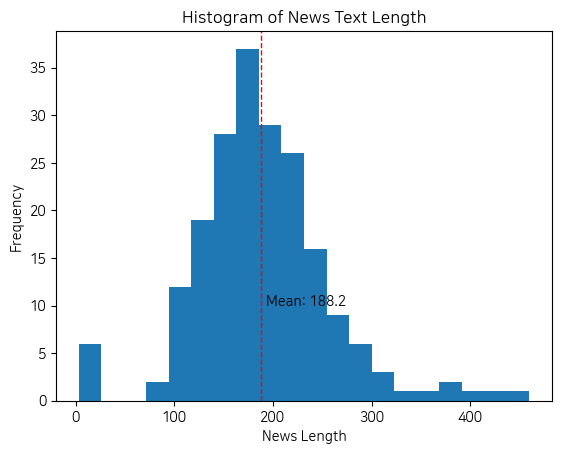

In [11]:
# Plot histogram of news text lengths based on extracted words
df['words'].apply(len).plot.hist(bins=20, 
                                 title='Distribution of News Lengths',
                                 xlabel='News Length')

mean_len = df['words'].apply(len).mean()
# Add a vertical line for the mean length
plt.axvline(mean_len, color='red', linestyle='dashed', linewidth=1)
# Add text annotation for the mean length
plt.text(mean_len+5, 10, 'Mean: {:.1f}'.format(mean_len), color='black')
# title
plt.title('Histogram of News Text Length')
plt.show()

In [12]:
# Show articles with less than 50 extracted words
df[df['words'].apply(len) < 50]


,title,text,url,publisher,dt,len,words
95,EL SALVADOR SOCCER,"epa12549199 Yamil Bukele, president of the gov...",https://v.daum.net/v/PBunC1DgZC,연합뉴스,2025.11.26 13:24,398,"[12549199, 2025-2029, 25, 2025]"
98,BRAZIL SOCCER,"epa12549150 The director of NR Sports, Neymar ...",https://v.daum.net/v/ux11C1DgGF,연합뉴스,2025.11.26 13:01,373,"[12549150, 25, 2025]"
99,BRAZIL SOCCER,epa12549154 Former Brazilian player Pepe react...,https://v.daum.net/v/9OsvcvLxXd,연합뉴스,2025.11.26 13:01,365,"[12549154, 25, 2025]"
100,BRAZIL SOCCER,epa12549152 An illuminated mural of Pele next ...,https://v.daum.net/v/GXlGrGjJXO,연합뉴스,2025.11.26 13:01,349,"[12549152, 25, 2025]"
101,BRAZIL SOCCER,"epa12549155 Flavia Arantes, Pele's daughter, s...",https://v.daum.net/v/9p4uWuCE5X,연합뉴스,2025.11.26 13:01,343,"[12549155, 25, 2025]"
105,BRAZIL SOCCER,epa12549143 Bruno Pinto (L) of Flamengo celebr...,https://v.daum.net/v/fZH16aKpHl,연합뉴스,2025.11.26 12:45,260,"[12549143, 25, 2025]"


In [13]:
# Keep only articles with 50 or more extracted words
df = df[df['words'].apply(len) >= 50]

#### 3. Draw Word Cloud

1. Without any preprocessing

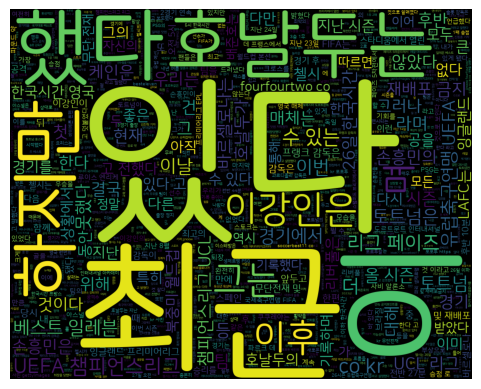

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


corpus = df['text']

text = ' '.join(corpus) # all text documents in one string
wc = WordCloud(font_path='NanumSquareRoundR.ttf', width=1000, height=800, max_words=1000).generate(text)
plt.imshow(wc)
plt.axis("off")
plt.show()

2. After applying NLP

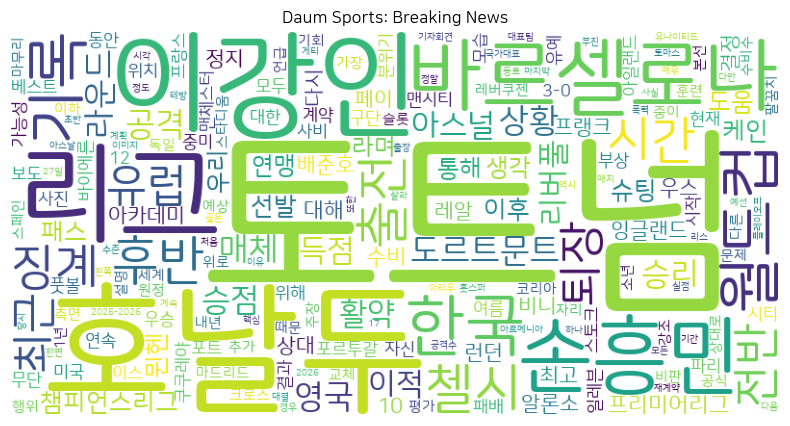

In [15]:
import itertools
from collections import Counter

import matplotlib.pyplot as plt
from wordcloud import WordCloud

def flatten_list(list_of_lists):
    return list(itertools.chain.from_iterable(list_of_lists))

def draw_wordcloud(words, title=None):
    word_freq = Counter(words)
    wordcloud = WordCloud(font_path='./NanumSquareRoundR.ttf', 
                          width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


words_all = flatten_list(df['words'])
draw_wordcloud(words_all, title='Daum Sports: Breaking News')

In [16]:
# To check word frequencies, you can use the following:
Counter(words_all).most_common(20)

[('토트넘', 391),
 ('호날두', 326),
 ('이강인', 245),
 ('리그', 236),
 ('바르셀로나', 236),
 ('손흥민', 234),
 ('한국', 221),
 ('월드컵', 202),
 ('기록', 199),
 ('첼시', 197),
 ('출전', 193),
 ('후반', 193),
 ('시간', 181),
 ('징계', 175),
 ('퇴장', 171),
 ('전반', 166),
 ('유럽', 153),
 ('최근', 152),
 ('도르트문트', 144),
 ('매체', 144)]

#### 4. Further Exploration

Can we draw wordclouds for the top-3 keywords: `토트넘`, `호날두`, `이강인`?

In [17]:
def draw_related_wordcloud(df, keyword, show_headlines=False):
    # Filter rows for articles containing the keyword
    df_kw = df[df['text'].str.contains(keyword)]
    # words_kw = df.loc[df['text'].apply(lambda x: keyword in x), 'words'] # alternative
    # words_kw = df.loc[df['words'].apply(lambda x: keyword in x), 'words'] # alternative

    # Flatten the list of lists into a single list
    words_kw = flatten_list(df_kw['words'])

    draw_wordcloud(words_kw, title=f'Daum Sports: Articles related to "{keyword}"')

    if show_headlines:
        print(df_kw['title'])

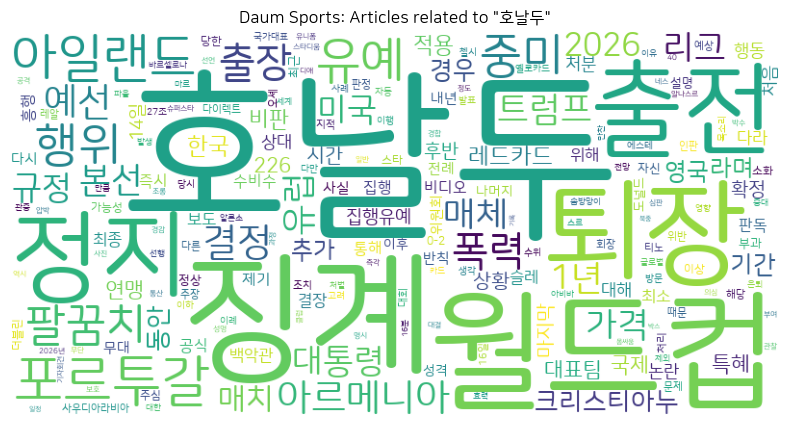

18              '퇴장' 호날두, 마지막 월드컵 정상적으로 뛴다... FIFA 징계 유예
19     "호날두와 트럼프가 만난지 6일 만에 FIFA 판정 나왔다!" 美 매체 조차 지적....
38              '퇴장' 호날두, 마지막 월드컵 정상적으로 뛴다... FIFA 징계 유예
39     "호날두와 트럼프가 만난지 6일 만에 FIFA 판정 나왔다!" 美 매체 조차 지적....
59                    FIFA, 호날두에 이례적 집행유예…월드컵 본선 출전 길 열려
63     사상 초유의 감독 경질 요구, 레알에서 터질까..."비니시우스와 갈등 폭발"→알론소...
65     비매너 파울로 레드카드 받고 퇴장당했는데 집행유예로 월드컵 출전 가능? FIFA의 ...
70     '트럼프 특혜 논란' 호날두 '이례적' 집행유예! 역대급 솜방망이 징계... '라스...
82           A매치 첫 적신에도 유예 처분...호날두, 월드컵 조별리그 첫 경기 출전 가능
87     '특혜두' 호날두, 팔꿈치 가격→출전 정지 징계 '집행유예'…"전례 없는 결정, 정...
90     무법자 호날두, 'NO SHOW' 이어 'NO 징계'…트럼프 특별사면 받았나→팔꿈치...
106    'FIFA 호날두 특혜 논란'…호날두 없다고 월드컵 포스터 수정→호날두 퇴장 징계 ...
117    폭행했는데 집행유예라니...트럼프와 만난 호날두, 북중미 월드컵 본선 출전 문제 없...
120    트럼프 만나고 징계 완화? '팔꿈치 퇴장' 호날두, 마지막 월드컵 뛴다…"공정성 무...
121    'FIFA식 호날두 살리기?' 팔꿈치 휘둘러도 '2경기 집행 유예', 북중미 월드컵...
128             '팔꿈치 가격→퇴장' 호날두, 월드컵 첫 경기 출전 가능…1년 집행 유예
129    '최강 10대' 맞대결서 '발롱도르 2위' 야말이 완패했다... 야유 세례 속 '굴...
132                      호날두, 추

In [ ]:
# Draw wordcloud for articles related to '호날두' and show headlines
draw_related_wordcloud(df, '호날두', show_headlines=True)

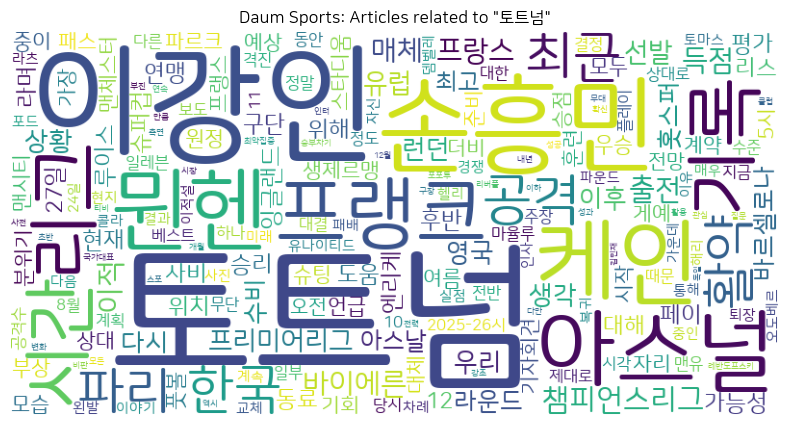

2      손흥민 초청 이유?.. '레비 떠난' NEW 토트넘, 아이콘 통해 '팬심 결속+정체...
5      "아직 손흥민 수준 도달 못했다"...여전히 SON 찾는 프랭크, 토트넘 공격 부진...
7      ‘토트넘전 영웅’ 이강인 하나로 행복한 PSG…훈련서 알까기 굴욕→동료들 애정 듬뿍...
8      이강인, 토트넘 상대로 또 한번 득점포 가동할까?... 김민재는 '英 1위' 아스날...
12           '북런던 더비 참패' 토트넘 감독 "손흥민 수준 대체자, 아직 시간이 필요해"
                             ...                        
176    "정말 죄송합니다. 사과드립니다" 토트넘 집단 사과 사태...손흥민 시대 후 최악의 참패
186     “토트넘은 공격도 수비도 잘한다” 흐비차 칭찬에…팬들 황당 “북런던 더비 안 봤나 봐”
191    "나 60살인데 내 평생 토트넘이 PL에서 우승한 적 없어"…'역대급' 손흥민 칭찬...
196    성추행 퇴출 기자도 이강인 인정..."더 이상 이강인은 끔찍하지 않다"→르 아브르전...
197    PSG 이강인, 토트넘 상대로 득점 할까…뮌헨 김민재는 ‘PL 1위’ 아스날 원정 나선다
Name: title, Length: 63, dtype: object


In [ ]:
# Draw wordcloud for articles related to '토트넘' and show headlines
draw_related_wordcloud(df, '토트넘', show_headlines=True)

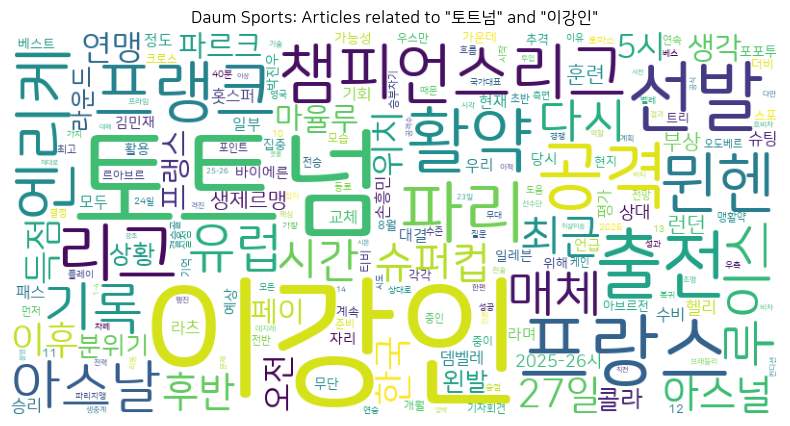

5      "아직 손흥민 수준 도달 못했다"...여전히 SON 찾는 프랭크, 토트넘 공격 부진...
7      ‘토트넘전 영웅’ 이강인 하나로 행복한 PSG…훈련서 알까기 굴욕→동료들 애정 듬뿍...
8      이강인, 토트넘 상대로 또 한번 득점포 가동할까?... 김민재는 '英 1위' 아스날...
17     ‘프랭크 감독 악수 패싱 논란’ 얼마나 됐다고…“토트넘 일부 선수들, 감독 전술 방...
25     "아직 손흥민 수준 도달 못했다"...여전히 SON 찾는 프랭크, 토트넘 공격 부진...
27     ‘토트넘전 영웅’ 이강인 하나로 행복한 PSG…훈련서 알까기 굴욕→동료들 애정 듬뿍...
28     이강인, 토트넘 상대로 또 한번 득점포 가동할까?... 김민재는 '英 1위' 아스날...
37     ‘프랭크 감독 악수 패싱 논란’ 얼마나 됐다고…“토트넘 일부 선수들, 감독 전술 방...
41     'PSG 주축 선수 도약' 이강인, 토트넘전 선발 제외 엇갈린 전망…루이스 엔리케 ...
45            '3경기 연속 맹활약' 이강인 이름 없다! 토트넘전 예상 선발 라인업서 제외
66     이강인, 치욕의 '알까기' 당했다…잔디 위 '풀썩'→상의 벗겨질 정도로 벌칙→'이것...
74     결국 ‘손흥민’ 이름 꺼낸 프랭크 감독…“토트넘 레전드 쏘니를 대신할 수준에 이르지...
75     '초비상' 토트넘 진짜 큰일 났다! 이강인도 모자라 '발롱도르 에이스' 부상 복귀…...
79     "이강인 어떻게 막나" 손흥민, 떠나자 토트넘 '킬러' 우뚝→2G 연속골 정조준…'...
83       '충격' 이강인이 없다...UCL 토트넘전 다시 벤치 전락 전망→19살 선수에 밀리나
102    얼마나 잘하면 '미쳤다' 극찬받는 이강인... '원더 중거리포' 꽂아버린 토트넘전 ...
110    "토트넘은 강팀, 하지만…" UEFA 슈퍼컵 역전승 떠올린 루이스 엔리케 PSG 감...
145     '파리 시민을 기쁘게하는 선수, 경기 거듭

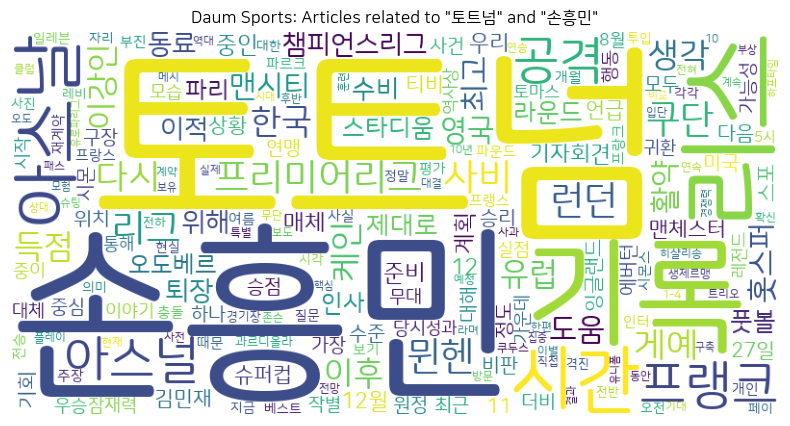

2      손흥민 초청 이유?.. '레비 떠난' NEW 토트넘, 아이콘 통해 '팬심 결속+정체...
5      "아직 손흥민 수준 도달 못했다"...여전히 SON 찾는 프랭크, 토트넘 공격 부진...
8      이강인, 토트넘 상대로 또 한번 득점포 가동할까?... 김민재는 '英 1위' 아스날...
12           '북런던 더비 참패' 토트넘 감독 "손흥민 수준 대체자, 아직 시간이 필요해"
22     손흥민 초청 이유?.. '레비 떠난' NEW 토트넘, 아이콘 통해 '팬심 결속+정체...
25     "아직 손흥민 수준 도달 못했다"...여전히 SON 찾는 프랭크, 토트넘 공격 부진...
28     이강인, 토트넘 상대로 또 한번 득점포 가동할까?... 김민재는 '英 1위' 아스날...
32           '북런던 더비 참패' 토트넘 감독 "손흥민 수준 대체자, 아직 시간이 필요해"
43     英 단독 떴다, 토트넘 ‘파격 대우’ 재계약 준비…“레전드이자 GOAT” 손흥민 무...
50     [UCL WORST] 손흥민 후계자로 1400억 쓸 뻔했다...맨시티 욕받이 전락한...
62             "손흥민 대체하려면 시간이 걸린다" PSG전 앞두고 SON 이름 나온 이유
71     "요리스가 손흥민 등 밀쳤다" 英 BBC, 5년 전 사건 재소환...동료 빰 때려 ...
74     결국 ‘손흥민’ 이름 꺼낸 프랭크 감독…“토트넘 레전드 쏘니를 대신할 수준에 이르지...
81     '쏘니의 영원한 주장' 공식 발표, 은퇴설 종식 "LAFC 잔류"...1년 더 SO...
91     “12월 21일 런던으로 돌아간다” 손흥민,. “인사할 자격 있다”… 손흥민·토트넘...
92     '바이아웃 1100억' 쏘니 절친, 직접 입 열었다...'바르셀로나 이적설' 전면 ...
103    "10년 레전드가 돌아온다"…손흥민, 12월 '토트넘 성지' 전격 귀환!→헌정식+스...
109    "끔찍, 형편 없어, 감옥 가야" 토트넘 1

In [ ]:
# New function to draw wordclouds for articles containing both keywords
def draw_related_wordcloud_two_keywords(df, keyword1, keyword2, show_headlines=False):
    # Filter rows for articles containing more than two keywords
    df_kw = df[df['text'].str.contains(keyword1) & df['text'].str.contains(keyword2)]

    # Flatten the list of lists into a single list
    words_kw = flatten_list(df_kw['words'])

    draw_wordcloud(words_kw, title=f'Daum Sports: Articles related to "{keyword1}" and "{keyword2}"')

    if show_headlines:
        print(df_kw['title'])


# Draw wordcloud for articles related to '토트넘' and '이강인' and show headlines
draw_related_wordcloud_two_keywords(df, '토트넘', '이강인', show_headlines=True)
# Draw wordcloud for articles related to '토트넘' and '손흥민' and show headlines
draw_related_wordcloud_two_keywords(df, '토트넘', '손흥민', show_headlines=True)